<a href="https://colab.research.google.com/github/engmodu/AIFEL_quest_eng/blob/main/Computer_Vision/CV02/cv3_03_3D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# cv2: OpenCV 라이브러리로, 실시간 컴퓨터 비전을 목적으로 한 프로그래밍 라이브러리
# numpy(NumPy): 행렬이나 대규모 다차원 배열을 쉽게 처리할 수 있도록 지원하는 라이브러리. 데이터 구조 외에도 수치 계산을 위해 효율적으로 구현된 기능을 제공
# torch: PyTorch. 딥러닝 및 텐서 연산을 위한 라이브러리. 인공지능 모델을 만들거나 불러와 추론하는 도구
# torchvision: 이미지 변환 및 전처리를 위한 torchvision의 transform 모듈
# deeplabv3_resnet101: 사전 학습된 DeepLabV3 모델. 이미지를 분류하도록 학습된 모델
# matplotlib: 파이썬 프로그래밍 언어 및 수학적 확장 NumPy 라이브러리를 활용한 플로팅 라이브러리로, 데이터 시각화 도구

import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt
from PIL import Image

print(cv2.__version__)

from google.colab import drive
drive.mount('/content/drive')



4.13.0
Mounted at /content/drive


In [3]:
# -------------------------
# 1. 경로 설정
# -------------------------
home_dir = os.path.join('/content/drive/MyDrive/data/')
cat_img_path = os.path.join(home_dir, 'human_segmentation/images/spaceCat.png')
sand_img_path = os.path.join(home_dir, 'human_segmentation/images/sand.png')

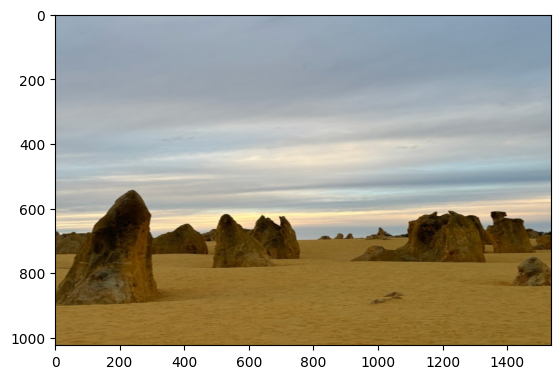

In [4]:
# -------------------------
# 2. 이미지 로드 (PIL 기준 통일)
# -------------------------
cat_img = Image.open(cat_img_path).convert("RGB")
sand_img = Image.open(sand_img_path).convert("RGB")

# 크기 통일 (중요)
sand_img = sand_img.resize(cat_img.size)

# numpy 변환
cat_np = np.array(cat_img)
sand_np = np.array(sand_img)

plt.imshow(sand_img)
plt.show()

In [5]:
# -------------------------
# 3. segmentation 모델
# -------------------------
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.Resize((520, 520)),
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:01<00:00, 163MB/s]


In [6]:
# -------------------------
# 4. segmentation 실행
# -------------------------
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    mask = output.argmax(0).byte().cpu().numpy()

# cat class = 8
cat_mask = (mask == 8).astype(np.uint8)

# 원본 크기로 복원 (VERY 중요)
cat_mask = cv2.resize(cat_mask, (cat_np.shape[1], cat_np.shape[0]), interpolation=cv2.INTER_NEAREST)


In [7]:
# -------------------------
# 5. foreground / background 분리
# -------------------------
foreground = cat_np * cat_mask[:, :, None]
background = sand_np * (1 - cat_mask[:, :, None])

# 합성
composite = foreground + background

In [8]:
# -------------------------
# 6. depth 생성 (가짜 3D)
# -------------------------
h, w = cat_mask.shape
depth = np.ones((h, w)) * 0.8   # 배경

# 고양이는 가까움
depth[cat_mask == 1] = 0.2

# 부드럽게 (품질 핵심)
depth = cv2.GaussianBlur(depth, (31, 31), 0)



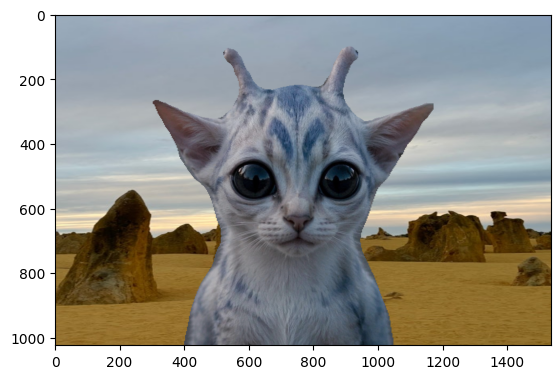

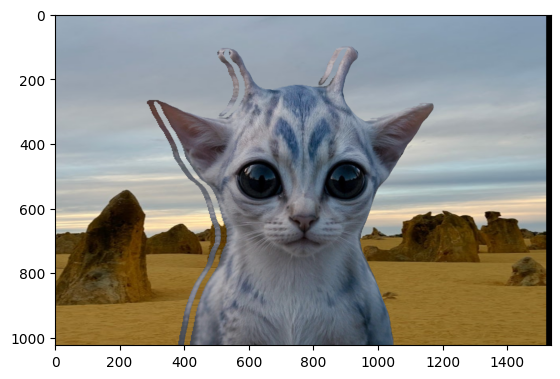

In [11]:
# -------------------------
# 7. parallax 변형
# -------------------------
shift_strength = 60

map_x, map_y = np.meshgrid(np.arange(w), np.arange(h))
shift = (depth - 0.5) * shift_strength

map_x = (map_x + shift).astype(np.float32)

warped = cv2.remap(composite, map_x, map_y.astype(np.float32), cv2.INTER_LINEAR)

plt.imshow(composite)
plt.show()
plt.imshow(warped)
plt.show()

In [10]:
# -------------------------
# 8. 결과 저장
# -------------------------
cv2.imwrite(os.path.join(home_dir, "composite.png"), composite)
cv2.imwrite(os.path.join(home_dir, "result_3d.png"), warped)

print("완료:")
print(" - composite.png (합성 이미지)")
print(" - result_3d.png (3D 효과)")

완료:
 - composite.png (합성 이미지)
 - result_3d.png (3D 효과)
